In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("datos_resultados_modularizado/datos_clusterizados_todos_5dc3.csv")
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc
# Crear objetos SkyCoord vectorizados
coords = SkyCoord(ra=df['ra'].values * u.degree,
                  dec=df['dec'].values * u.degree,
                  distance=df['distance_pc'].values * u.pc,
                  frame='icrs')

# Extraer coordenadas cartesianas
df['x_pc'] = coords.cartesian.x.value
df['y_pc'] = coords.cartesian.y.value
df['z_pc'] = coords.cartesian.z.value
df['probabilidad'] = df['ConteoAgrupaciones']/400

In [3]:
df['l'] = coords.galactic.l.degree  # longitud galáctica
df['b'] = coords.galactic.b.degree 
df['l_rad'] = np.radians(df['l'].values - 180)   # longitud galáctica
df['b_rad'] = np.radians(df['b'].values)

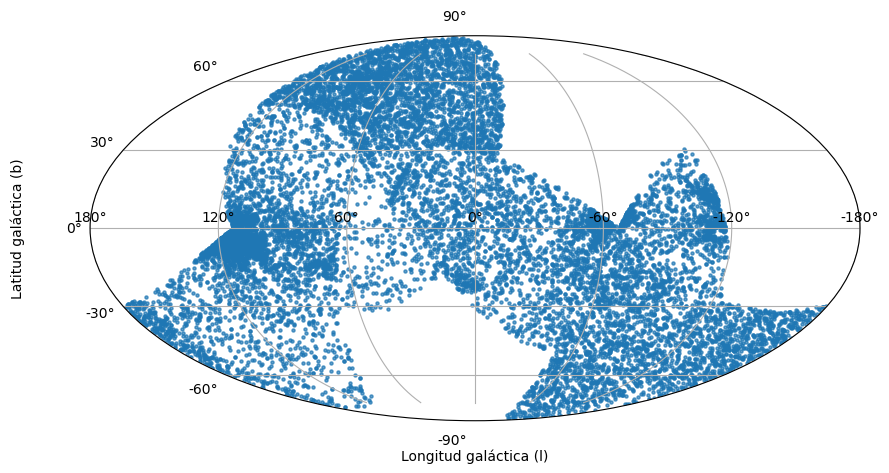

In [4]:
l = df['l'].values
b = df['b'].values

# Convertir a radianes para Mollweide
l_rad = np.radians(l - 180)  # Recentrar en 0°
b_rad = np.radians(b)

# Crear figura
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot
ax.scatter(l_rad, b_rad, s=5, alpha=0.7)

# Grid cada 30° latitud, 60° longitud
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))

ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])

ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
plt.show()

In [5]:
def silhouette_por_cluster_dataframe(df, cluster_col='cluster', feature_cols=None):
    # Excluir ruido
    df_valido = df[df[cluster_col] != -1].copy()

    if feature_cols is None:
        # Detectar columnas numéricas automáticamente si no se especifican
        feature_cols = df_valido.select_dtypes(include=['float64', 'int64']).columns.tolist()
        feature_cols.remove(cluster_col)

    X = df_valido[feature_cols].values
    labels = df_valido[cluster_col].values

    # Calcular silhouette por muestra
    sil_values = silhouette_samples(X, labels)

    df_valido['silhouette'] = sil_values

    # Agrupar por clúster y calcular promedio
    silhouette_mean = df_valido.groupby(cluster_col)['silhouette'].mean()

    return silhouette_mean

def r2_por_cluster_dataframe(df, cluster_col='cluster', x_col='b_v', y_col='phot_g_mean_mag', calcular_rmse=True, calcular_residual_std=True):
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []

    for cluster, grupo in df_valido.groupby(cluster_col):
        if len(grupo) < 2:
            continue

        X = grupo[[x_col]].values
        y = grupo[y_col].values

        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)
        r2 = r2_score(y, y_pred)**2 # modificado

        resultado_cluster = {
            cluster_col: cluster,
            'r2': r2
        }

        if calcular_rmse:
            rmse = mean_squared_error(y, y_pred, squared=False)
            resultado_cluster[f'rmse_{y_col}_vs_{x_col}'] = rmse

        if calcular_residual_std:
            residuos = y - y_pred
            std_residuos = np.std(residuos)
            resultado_cluster[f'std_residuos_{y_col}_vs_{x_col}'] = std_residuos

        resultados.append(resultado_cluster)

    return pd.DataFrame(resultados)

def dispersion_por_cluster(df, cluster_col='cluster', variable='phot_g_mean_mag', metodo='std'):
    df_valido = df[df[cluster_col] != -1].copy()

    if metodo == 'std':
        dispersion = df_valido.groupby(cluster_col)[variable].std().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_std'})
    elif metodo == 'var':
        dispersion = df_valido.groupby(cluster_col)[variable].var().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_var'})
    elif metodo == 'iqr':
        dispersion = df_valido.groupby(cluster_col).agg(
            Q3=(variable, lambda x: np.percentile(x, 75)),
            Q1=(variable, lambda x: np.percentile(x, 25))
        )
        dispersion['iqr'] = dispersion['Q3'] - dispersion['Q1']
        dispersion = dispersion.reset_index()[[cluster_col, 'iqr']]
        dispersion = dispersion.rename(columns={'iqr': f'dispersion_{variable}_iqr'})
    else:
        raise ValueError("Método no soportado. Usa 'std', 'var' o 'iqr'.")

    return dispersion

def escalar_columnas(df, columnas, nuevo_min=0, nuevo_max=5):
    df_escalado = df.copy()
    for col in columnas:
        min_val = df[col].min()
        max_val = df[col].max()
        if min_val == max_val:
            df_escalado[col + '_esc'] = nuevo_min  # o 0 si no hay variación
        else:
            df_escalado[col + '_esc'] = nuevo_min + (df[col] - min_val) * (nuevo_max - nuevo_min) / (max_val - min_val)
    return df_escalado

def filtrar_clusters_destacados(df, columnas_originales, columnas_escaladas, percentil=0.9):
    df_filtrado = df.copy()

    # Paso 1: Filtrar donde todas las métricas originales sean > 0
    for col in columnas_originales:
        df_filtrado = df_filtrado[df_filtrado[col] > 0]

    # Paso 2: Filtrar donde todas las métricas escaladas estén en el top percentil
    for col in columnas_escaladas:
        umbral = df[col].quantile(percentil)
        df_filtrado = df_filtrado[df_filtrado[col] >= umbral]

    return df_filtrado

In [6]:
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)

In [7]:
dff = df[df['cluster']>0].copy()

In [8]:
dff['abs'] = dff['phot_g_mean_mag'] - 5*np.log10(1000/dff['parallax'])+5

In [9]:
feature_cols = ['pmra_norm', 'pmdec_norm','parallax_norm']
silhouette_por_cluster = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=feature_cols).reset_index()
silhouette_por_distancia = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['x_pc','y_pc','z_pc']).reset_index()
silhouette_por_movimientos = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['pmra_norm','pmdec_norm']).reset_index()
r2_clusters = r2_por_cluster_dataframe(dff.dropna(subset=['phot_g_mean_mag','bp_rp']), cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag',calcular_residual_std = False)
dispersion_magnitud = dispersion_por_cluster(dff, variable='phot_g_mean_mag', metodo='std')
probabilidad_cluster = dff.groupby(['cluster']).agg({'probabilidad':'median','source_id':'count'}).reset_index()
silhouette_por_cluster = silhouette_por_cluster\
                        .merge(probabilidad_cluster, how='inner', on=['cluster'])\
                        .merge(silhouette_por_distancia.rename(columns={'silhouette':'silhouette_distancia'}), how='inner', on=['cluster'])\
                        .merge(silhouette_por_movimientos.rename(columns={'silhouette':'silhouette_movimientos'}), how='inner', on=['cluster'])\
                        .merge(r2_clusters, how='inner', on='cluster')\
                        .merge(dispersion_magnitud, how='inner', on='cluster')
# Columnas que vas a escalar
columnas_a_escalar = ['silhouette', 'silhouette_distancia', 'silhouette_movimientos', 'probabilidad', 'r2', "rmse_phot_g_mean_mag_vs_bp_rp"]

# Escalamos al rango 0-5
silhouette_por_cluster = escalar_columnas(silhouette_por_cluster, columnas=columnas_a_escalar)

# Calculamos métrica global como suma de las columnas escaladas
columnas_escaladas = [col + '_esc' for col in columnas_a_escalar]
silhouette_por_cluster = silhouette_por_cluster[silhouette_por_cluster['silhouette_distancia']>0]

C:\Users\nicob\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nicob\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nicob\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nicob\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

In [10]:
silhouette_por_cluster['metrica'] = silhouette_por_cluster[['silhouette_distancia', 'probabilidad', 'r2']].product(axis=1)

In [11]:
# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)

C:\Users\nicob\AppData\Local\Temp\ipykernel_22476\981530115.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.


In [12]:
# silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
                        # &(silhouette_por_cluster['probabilidad']>0.)\
                        # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(20)

,cluster,silhouette,probabilidad,source_id,silhouette_distancia,silhouette_movimientos,r2,rmse_phot_g_mean_mag_vs_bp_rp,dispersion_phot_g_mean_mag_std,silhouette_esc,silhouette_distancia_esc,silhouette_movimientos_esc,probabilidad_esc,r2_esc,rmse_phot_g_mean_mag_vs_bp_rp_esc,metrica
2,3,-0.110147,0.80000,95,0.255209,-0.682206,0.410354,1.873937,3.082628,1.218978,3.711840,0.000000,5.000000,5.000000,0.350791,8.378073e-02
24,110,-0.136232,0.79750,85,0.087781,-0.099022,0.297594,1.774306,2.632287,1.065768,2.268266,2.081445,4.984326,3.626057,0.000000,2.083324e-02
0,1,-0.117765,0.80000,430,0.122123,-0.097704,0.120694,2.473613,3.057320,1.174232,2.564363,2.086150,5.000000,1.470587,2.462198,1.179156e-02
12,15,-0.066156,0.79250,237,0.054489,0.294340,0.243430,2.541954,3.560318,1.477370,1.981215,3.485395,4.952978,2.966086,2.702820,1.051188e-02
26,211,-0.157586,0.69250,104,0.029975,0.209825,0.114788,2.485558,3.084267,0.940344,1.769851,3.183753,4.326019,1.398628,2.504254,2.382694e-03
17,25,0.051401,0.79750,204,0.010129,0.126073,0.231281,2.131729,2.977173,2.167853,1.598741,2.884834,4.984326,2.818055,1.258456,1.868263e-03
6,8,-0.126036,0.79500,81,0.040312,-0.420854,0.050824,2.347363,2.671518,1.125656,1.858979,0.932795,4.968652,0.619255,2.017683,1.628808e-03
1,2,0.211965,0.37750,77,0.010792,0.409743,0.305069,1.998427,3.006409,3.110948,1.604457,3.897282,2.351097,3.717139,0.789108,1.242842e-03
13,16,0.017931,0.54625,114,0.019118,0.216051,0.075834,2.714488,3.210352,1.971262,1.676241,3.205973,3.409091,0.923990,3.310297,7.919333e-04
16,24,-0.025484,0.04000,128,0.068188,-0.147646,0.087443,2.133938,2.538285,1.716256,2.099328,1.907903,0.235110,1.065438,1.266232,2.385005e-04


Text(0.5, 0, 'Métrica')

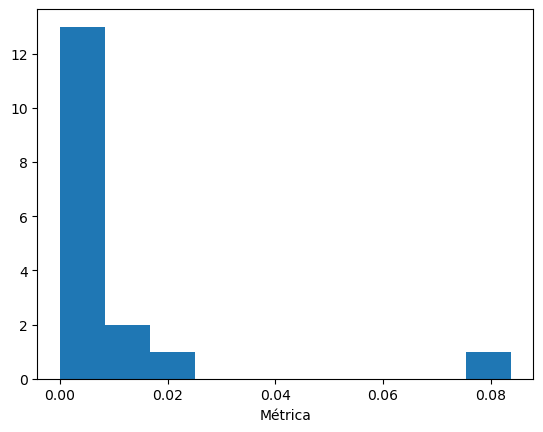

In [13]:
plt.hist(silhouette_por_cluster['metrica'])
plt.xlabel("Métrica")

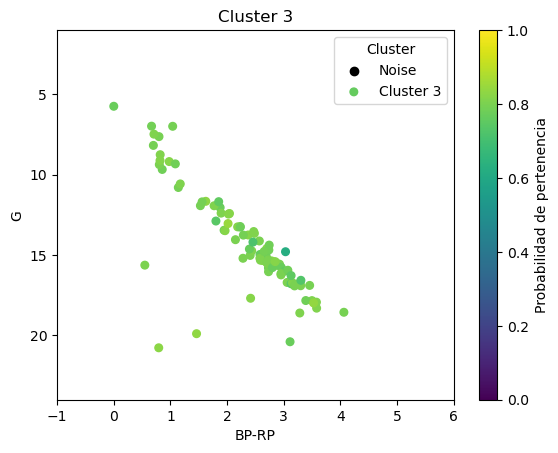

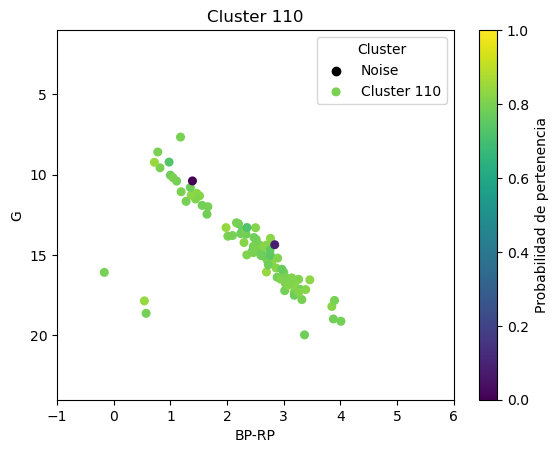

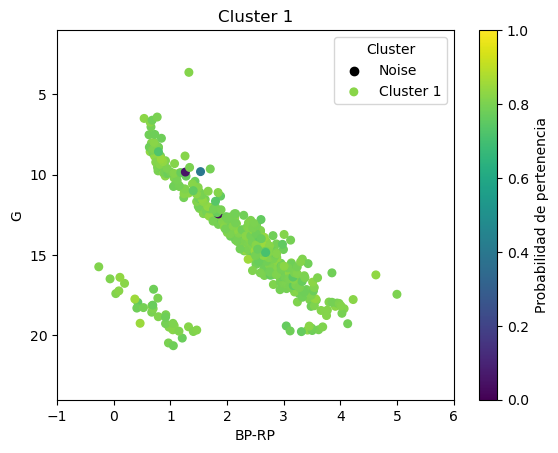

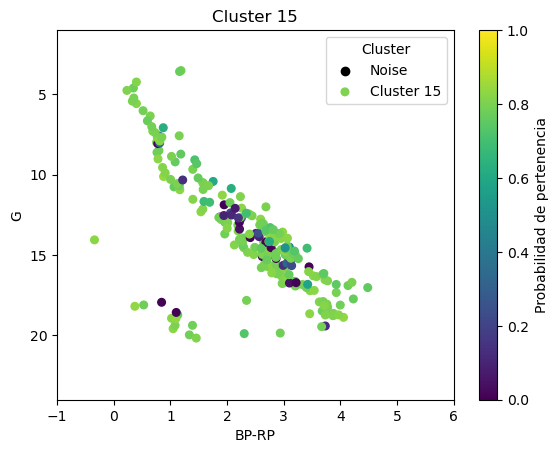

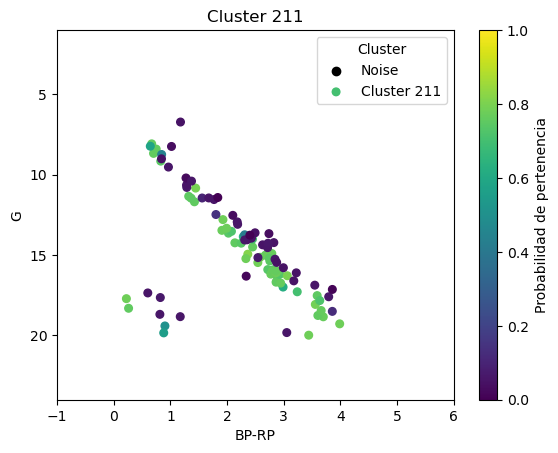

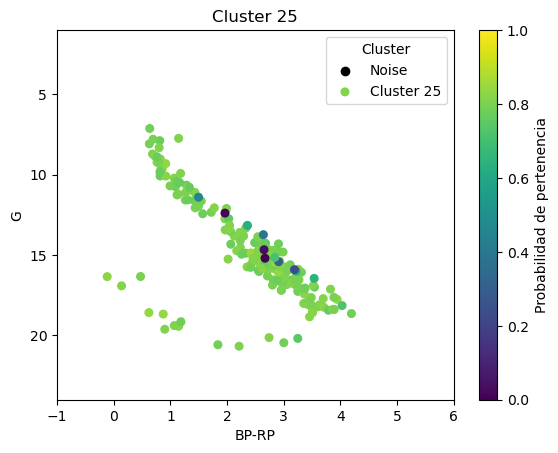

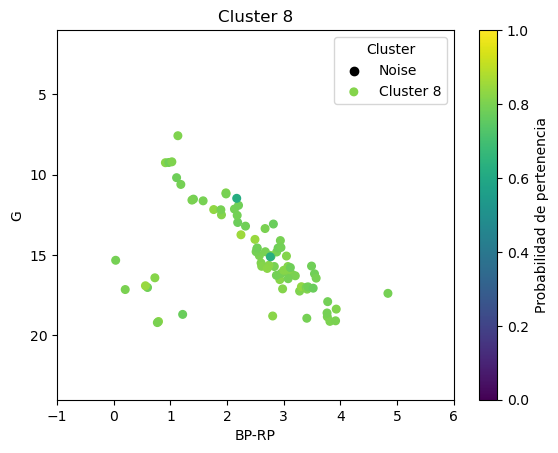

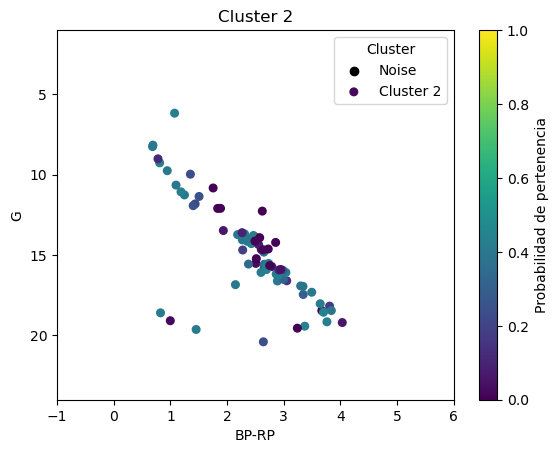

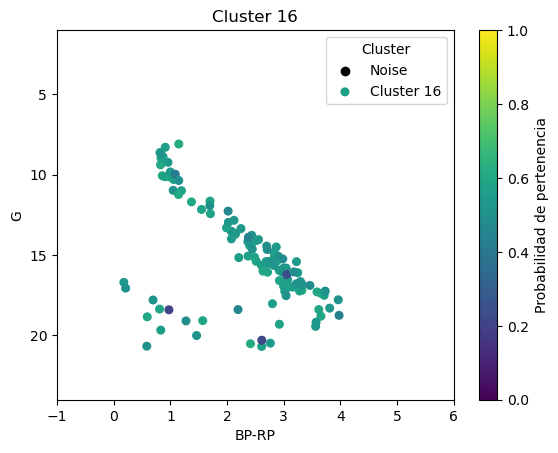

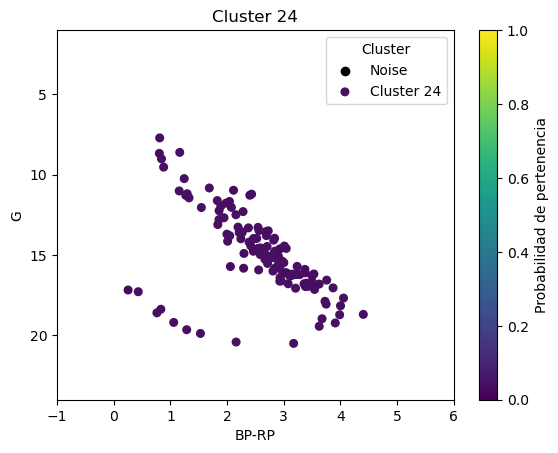

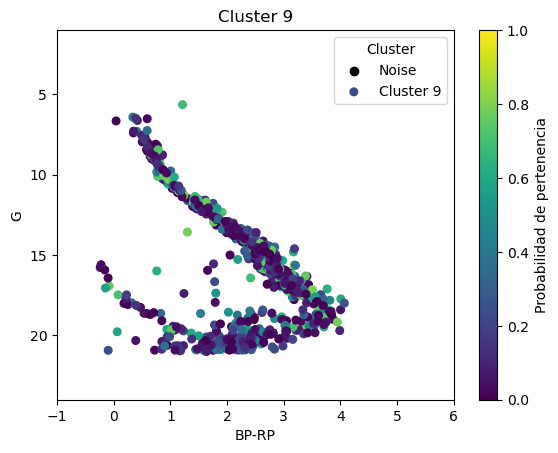

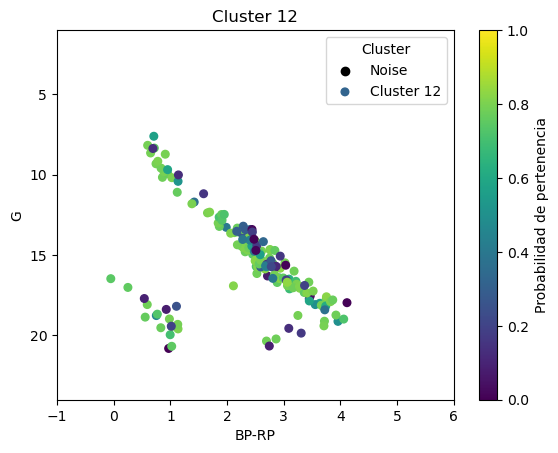

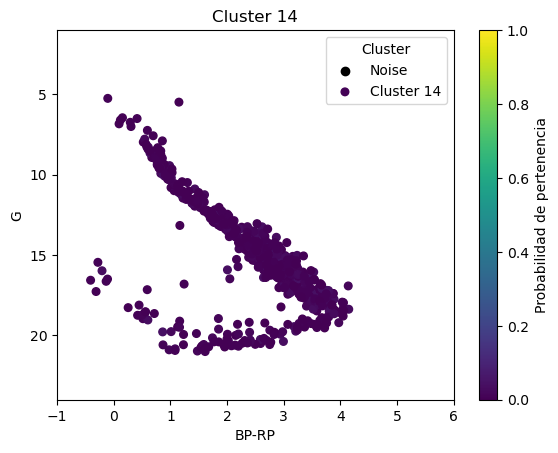

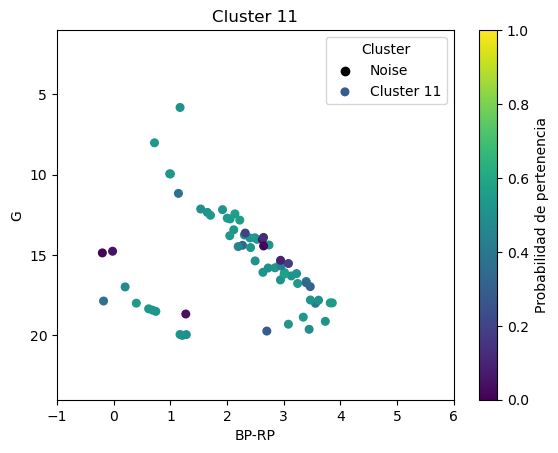

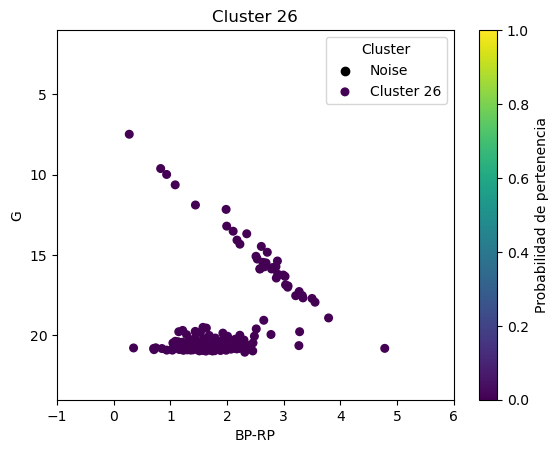

In [14]:
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(15)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

In [15]:
# graficar en latitud y longitud galactiva

C:\Users\nicob\AppData\Local\Temp\ipykernel_22476\2752474401.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  sc = plt.scatter(subset['bp_rp'], subset['abs'],


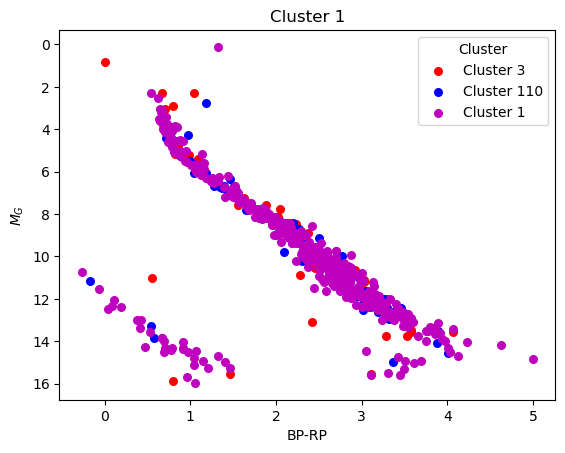

In [16]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

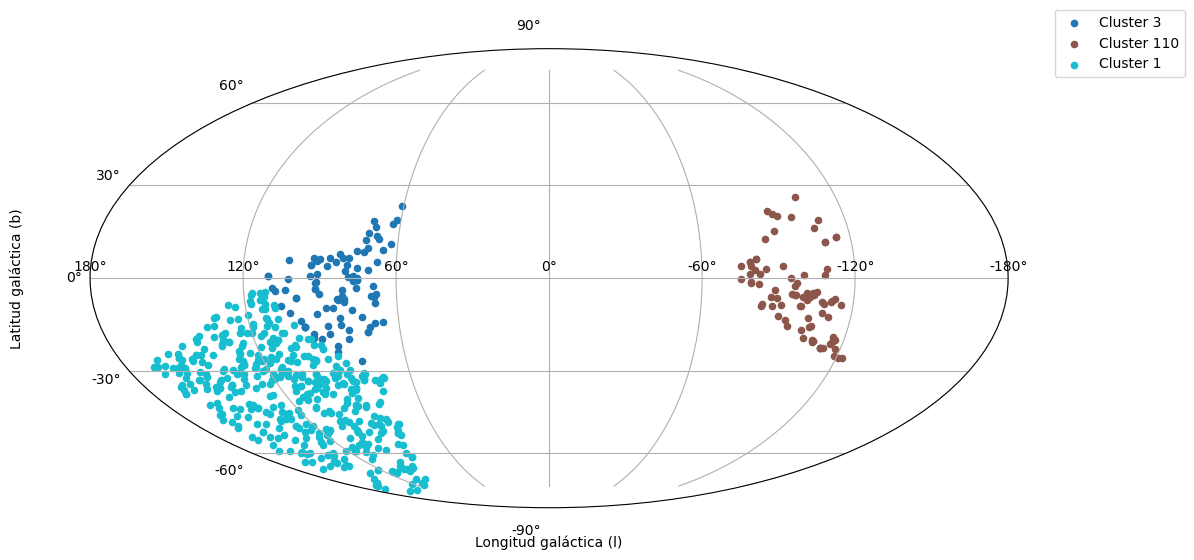

In [17]:
# Crear figura Mollweide
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Graficar por cada cluster
clusters = silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values
colors = plt.cm.tab10(np.linspace(0, 1, len(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values)))  # Paleta de colores
  # Paleta de colores

for cluster, color in zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values, colors):
    subset = dff[dff['cluster'] == cluster].reset_index(drop=True)
    ax.scatter(subset['l_rad'], subset['b_rad'], s=20, alpha=1, label=f'Cluster {cluster}', color=color)

# Etiquetas y rejilla
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])
ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()